# Assumption Junction — Generalized Additive Model (GAM)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ananya923/XAI_Week2_Activity/blob/main/Kedar_ASK_gam.ipynb)

**Team:** ASK &nbsp;|&nbsp; **Student:** Kedar &nbsp;|&nbsp; **Model:** Generalized Additive Model (Student 3)

**Team question:** *Which model should the telecom company use if it wants an interpretable churn model, and what assumptions should it worry about before acting on the explanation?*

This notebook fits a **logistic GAM** to the Telco Customer Churn dataset. A GAM keeps the additive, one-feature-at-a-time
structure that makes logistic regression readable, but replaces each straight-line term with a smooth spline
$f_j(x_j)$ that the data shapes itself:

$$\log\frac{p(\text{churn})}{1-p(\text{churn})} = \beta_0 + f_1(\text{tenure}) + f_2(\text{MonthlyCharges}) + \sum_j \beta_j \cdot \text{(categorical}_j)$$

Nothing is multiplied together, so every effect can still be read off a single plot. That is the interpretability
we are buying, and the additivity assumption is exactly what we have to defend.

**Notebook contents**

1. Dataset loading and cleaning
2. EDA relevant to GAM assumptions
3. GAM code
4. Model performance evidence
5. Smooth effect interpretation
6. Limitations of a GAM for churn

## 0. Setup

`pygam` is not preinstalled in Colab, so install it first. Everything else ships with Colab.

In [ ]:
%pip install pygam --quiet

In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pygam import LogisticGAM, LinearGAM, s, f
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

## 1. Dataset loading and cleaning

The **Telco Customer Churn** dataset (IBM sample data, `WA_Fn-UseC_-Telco-Customer-Churn.csv` in this repo) has
7,043 customers and 21 columns: demographics
(gender, senior citizen, partner, dependents), the services each customer subscribes to (phone, internet,
online security, tech support, streaming), account terms (contract type, paperless billing, payment method),
two dollar/time columns (`tenure` in months, `MonthlyCharges`, `TotalCharges`), and the label `Churn`
(did the customer leave in the last month).

Each row is one customer at one snapshot in time, so this is a cross-sectional binary classification task.

In [3]:
LOCAL_CSV = Path("WA_Fn-UseC_-Telco-Customer-Churn.csv")  # committed in the team repo
FALLBACK_URL = (
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
    "master/data/Telco-Customer-Churn.csv"
)

# Use the team's copy when running from a clone; fall back to the IBM source on a bare Colab runtime
source = LOCAL_CSV if LOCAL_CSV.exists() else FALLBACK_URL
raw = pd.read_csv(source)

print("Loaded from:", source)
print("Shape:", raw.shape)
print("Duplicate customerID values:", raw["customerID"].duplicated().sum())
print("\nMissing values per column (pandas view):")
print(raw.isna().sum().loc[lambda s: s > 0] if raw.isna().sum().any() else "None flagged by pandas")
raw.head()

Loaded from: WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape: (7043, 21)
Duplicate customerID values: 0

Missing values per column (pandas view):
None flagged by pandas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
raw.dtypes.to_frame("dtype").T

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
dtype,str,str,int64,str,str,int64,str,str,str,str,...,str,str,str,str,str,str,str,float64,str,str


`TotalCharges` arrives as an object column, not a float. That is the one real data-quality trap in this dataset:
11 rows hold a blank string. Those 11 customers all have `tenure == 0`, i.e. they were signed up but had not yet
been billed, and none of them churned.

In [5]:
blank_mask = pd.to_numeric(raw["TotalCharges"], errors="coerce").isna()
print("Rows with non-numeric TotalCharges:", blank_mask.sum())
raw.loc[blank_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]

Rows with non-numeric TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


**Cleaning decisions**

| Step | Decision | Reason |
|---|---|---|
| `TotalCharges` blanks | Drop the 11 rows | They are brand-new accounts with no billing history (`tenure = 0`); imputing a charge would invent history. 0.16% of the data. |
| `customerID` | Drop | Identifier, no predictive content, and keeping it would leak nothing but noise. |
| `"No internet service"` / `"No phone service"` | Recode to `"No"` | These are the same state as "No" but split across a third level, which thins out spline/factor cells for no gain. |
| `Churn` | Map to 1/0 | GAM needs a numeric binary target for the Bernoulli/logit setup. |
| `TotalCharges` as a predictor | Exclude | Nearly a deterministic function of `tenure × MonthlyCharges` — this is the concurvity check in section 2. |

In [6]:
df = raw.copy()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
df = df.drop(columns=["customerID"])

for col in [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]:
    df[col] = df[col].replace({"No internet service": "No"})
df["MultipleLines"] = df["MultipleLines"].replace({"No phone service": "No"})

df["Churn"] = (df["Churn"] == "Yes").astype(int)

print("Cleaned shape:", df.shape)
print("Churn rate: {:.3f}".format(df["Churn"].mean()))
print("\nClass balance:")
print(df["Churn"].value_counts().rename({0: "Stayed", 1: "Churned"}))

Cleaned shape: (7032, 20)
Churn rate: 0.266

Class balance:
Churn
Stayed     5163
Churned    1869
Name: count, dtype: int64


## 2. EDA relevant to GAM assumptions

A GAM relaxes the linearity assumption of logistic regression but keeps four others. These are the ones worth
checking *before* trusting any smooth we plot later:

| Assumption | What it means here | How I check it |
|---|---|---|
| **Correct link + distribution** | Churn is binary, so Bernoulli response with a logit link | Confirm target is 0/1, look at class balance |
| **Independent observations** | One row per customer, no repeat measures or clustering | Duplicate ID check, note on the snapshot design |
| **Smooth (not jumpy) effects** | Each continuous feature's effect on log-odds is a smooth curve with enough distinct values to estimate it | Empirical log-odds by bin for `tenure` and `MonthlyCharges` |
| **Additivity (no interactions)** | Effects add on the log-odds scale; the tenure curve is the *same* curve for every contract type | Churn rate by Contract × InternetService, and tenure curves split by contract |
| **Low concurvity** | The GAM analogue of multicollinearity: one predictor's smooth should not be reproducible from another's | Correlations plus a spline $R^2$ between the continuous predictors |

Notice which assumption is *not* in this table: linearity. Dropping it is the whole point of using a GAM,
and section 2.2 shows how badly linearity would have fit.

### 2.1 Response distribution and link function

Churn is binary and imbalanced at roughly 27/73. That confirms Bernoulli + logit is the right family, and it
also warns us that plain accuracy will be a misleading metric later — a model that predicts "nobody churns"
already scores 73%.

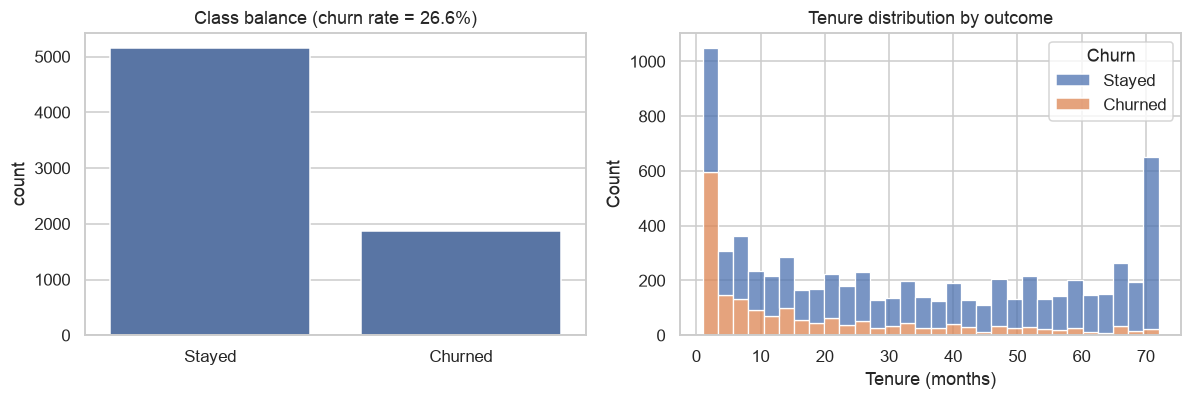

Baseline accuracy from always predicting 'Stayed': 0.734


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

sns.countplot(x=df["Churn"].map({0: "Stayed", 1: "Churned"}), ax=axes[0])
axes[0].set_title(f"Class balance (churn rate = {df['Churn'].mean():.1%})")
axes[0].set_xlabel("")

sns.histplot(data=df, x="tenure", hue=df["Churn"].map({0: "Stayed", 1: "Churned"}),
             bins=30, multiple="stack", ax=axes[1])
axes[1].set_title("Tenure distribution by outcome")
axes[1].set_xlabel("Tenure (months)")

plt.tight_layout()
plt.show()

print("Baseline accuracy from always predicting 'Stayed': {:.3f}".format(1 - df["Churn"].mean()))

### 2.2 Are the continuous effects smooth — and are they linear?

For a GAM, what matters is that each continuous predictor's effect on the **log-odds** is a smooth curve.
The check is to bin the predictor, compute the empirical log-odds of churn in each bin, and look at the shape.
A straight line means logistic regression would have been enough; a bend means the spline is earning its keep.

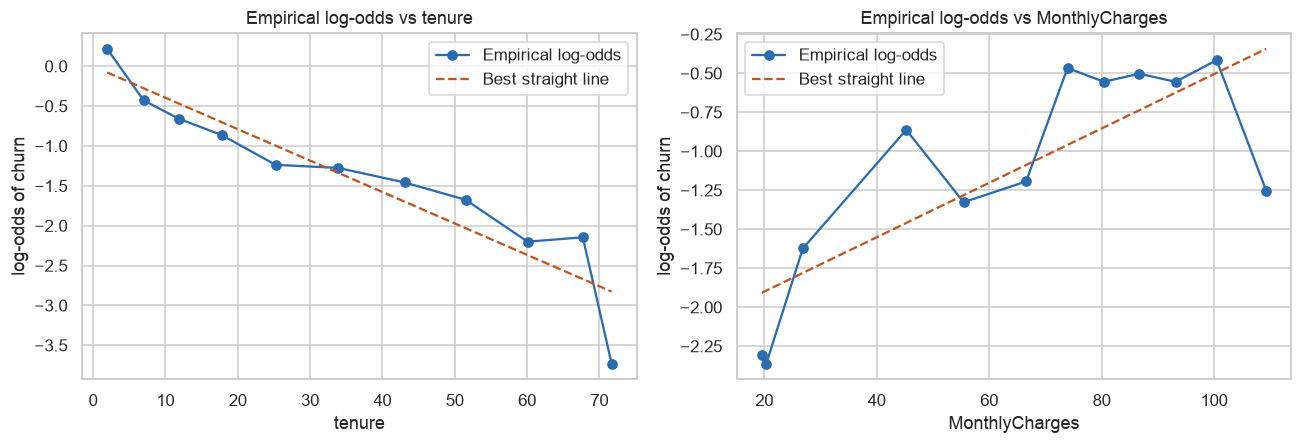

In [8]:
def empirical_logit(frame, column, bins=12, target="Churn"):
    # Log-odds of churn within equal-frequency bins of `column`
    binned = pd.qcut(frame[column], bins, duplicates="drop")
    grouped = frame.groupby(binned, observed=True).agg(
        x=(column, "mean"), rate=(target, "mean"), n=(target, "size")
    )
    # Haldane-Anscombe style correction keeps the log finite in all-or-nothing bins
    p = (grouped["rate"] * grouped["n"] + 0.5) / (grouped["n"] + 1.0)
    grouped["log_odds"] = np.log(p / (1 - p))
    return grouped


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for ax, col in zip(axes, ["tenure", "MonthlyCharges"]):
    g = empirical_logit(df, col)
    ax.plot(g["x"], g["log_odds"], "o-", color="#2b6cb0", label="Empirical log-odds")
    fit = np.polyfit(g["x"], g["log_odds"], 1)
    ax.plot(g["x"], np.polyval(fit, g["x"]), "--", color="#c05621", label="Best straight line")
    ax.set_xlabel(col)
    ax.set_ylabel("log-odds of churn")
    ax.set_title(f"Empirical log-odds vs {col}")
    ax.legend()

plt.tight_layout()
plt.show()

Both curves depart from the dashed straight line, which is the evidence that motivates a GAM here:

- **`tenure`** declines at a very uneven rate. Log-odds fall from **+0.22** in months 1–4 to **−0.43** in months
  5–9, a drop of 0.65 in about five months, then drift down by only ~0.2 per bin through the middle years,
  before falling off a cliff to **−3.73** in the final bin (months 70–72). The risk is front-loaded and
  back-loaded; a single slope would have to average three different regimes.
- **`MonthlyCharges`** is clearly non-monotone: **−2.31** near $20, up to **−0.86** near $45, back down to
  **−1.33** near $55, up again to **−0.42** near $100, then down to **−1.25** in the most expensive bin. A
  straight line through that is close to meaningless.

One caution before section 5: these binned curves are **marginal** — they ignore every other feature. The dip
in the top price bin is a good example of why that matters. Customers paying more than $104/month are 70%
one- or two-year contract holders with a mean tenure of 56 months, so their low churn rate is really their
contract and tenure showing through. The GAM's fitted smooth is a *conditional* effect that holds those other
features fixed, so it can point the other way, and it does.

Both variables have plenty of distinct values (72 tenure values, ~1,600 charge values), so there is enough
support to estimate a smooth rather than fit noise.

In [9]:
print("Distinct values — tenure: {}, MonthlyCharges: {}".format(
    df["tenure"].nunique(), df["MonthlyCharges"].nunique()))
print("\nChurn rate by tenure band:")
bands = pd.cut(df["tenure"], [-0.1, 3, 6, 12, 24, 36, 48, 60, 73])
print(df.groupby(bands, observed=True)["Churn"].agg(churn_rate="mean", customers="size").round(3))

Distinct values — tenure: 72, MonthlyCharges: 1584

Churn rate by tenure band:
              churn_rate  customers
tenure                             
(-0.1, 3.0]        0.568       1051
(3.0, 6.0]         0.446        419
(6.0, 12.0]        0.359        705
(12.0, 24.0]       0.287       1024
(24.0, 36.0]       0.216        832
(36.0, 48.0]       0.190        762
(48.0, 60.0]       0.144        832
(60.0, 73.0]       0.066       1407


### 2.3 Concurvity — the GAM version of multicollinearity

Concurvity is the reason `TotalCharges` is not in the model. In a GAM, two predictors are a problem not just
when they are linearly correlated, but when a *smooth function* of one can reproduce the other. When that
happens the fitted curves become unstable and the credit for an effect can shift arbitrarily between them,
which destroys the per-feature story we are trying to tell.

I measure it directly: fit a spline of one predictor against the other and report the $R^2$.

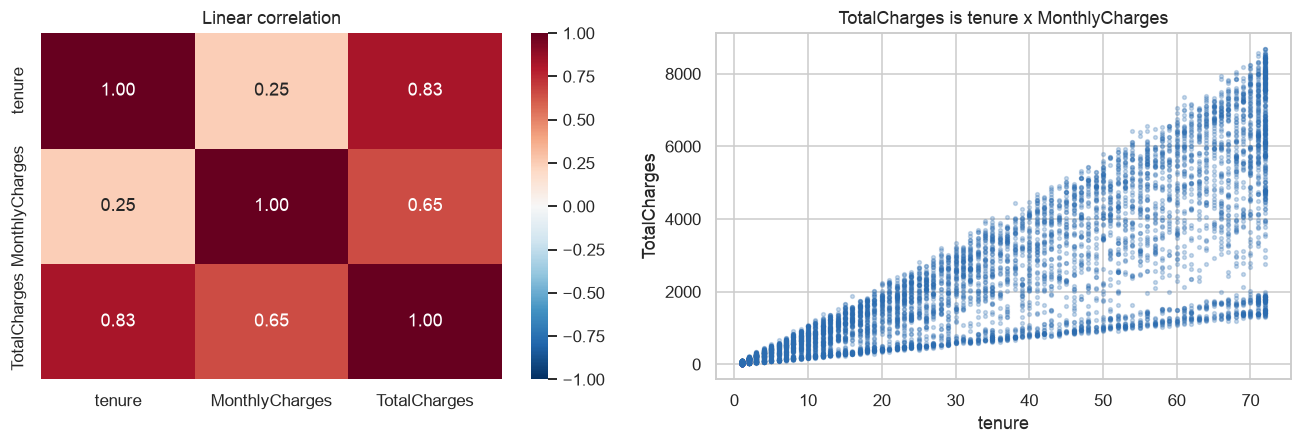

Smooth R^2, s(tenure) -> TotalCharges: 0.687
Smooth R^2, s(tenure) -> MonthlyCharges: 0.065


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

corr = df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Linear correlation")

axes[1].scatter(df["tenure"], df["TotalCharges"], s=6, alpha=0.25, color="#2b6cb0")
axes[1].set_xlabel("tenure")
axes[1].set_ylabel("TotalCharges")
axes[1].set_title("TotalCharges is tenure x MonthlyCharges")

plt.tight_layout()
plt.show()


def smooth_r2(predictor, target):
    # R^2 from fitting a single spline of `predictor` to `target`: a concurvity proxy
    model = LinearGAM(s(0)).gridsearch(df[[predictor]].values, df[target].values, progress=False)
    resid = df[target].values - model.predict(df[[predictor]].values)
    return 1 - resid.var() / df[target].values.var()


for predictor, target in [("tenure", "TotalCharges"), ("tenure", "MonthlyCharges")]:
    print(f"Smooth R^2, s({predictor}) -> {target}: {smooth_r2(predictor, target):.3f}")

A spline of `tenure` alone explains about **69%** of `TotalCharges`, and `TotalCharges` correlates 0.83 with
`tenure` and 0.65 with `MonthlyCharges`. It is close to redundant by construction (roughly tenure × monthly
bill), so including it would split one effect across two smooths and make both harder to read. I drop it.

`tenure` and `MonthlyCharges` against each other are a different story: the smooth $R^2$ is only about
**0.07**, so those two can safely sit in the same model.

### 2.4 Additivity — the assumption most at risk

This is the assumption a GAM does **not** relax, and the one I am most worried about. Additivity says the
tenure curve is the same shape for a month-to-month customer as for a two-year-contract customer, and that
the contract effect is a constant shift on the log-odds scale regardless of tenure.

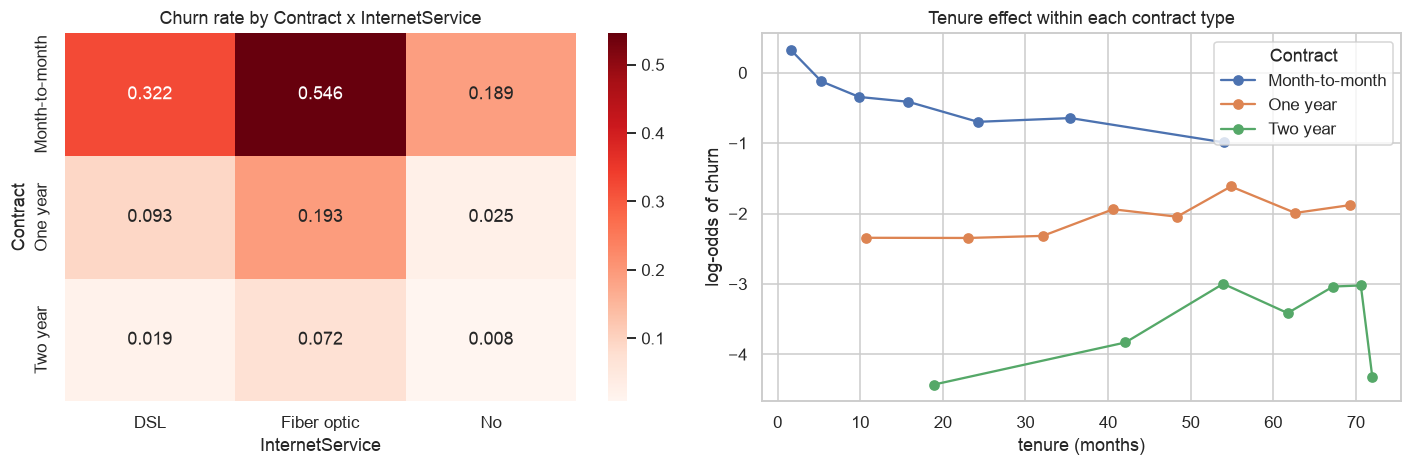

InternetService    DSL  Fiber optic     No
Contract                                  
Month-to-month   0.322        0.546  0.189
One year         0.093        0.193  0.025
Two year         0.019        0.072  0.008


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

pivot = pd.crosstab(df["Contract"], df["InternetService"], values=df["Churn"], aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Reds", ax=axes[0])
axes[0].set_title("Churn rate by Contract x InternetService")

for contract, sub in df.groupby("Contract"):
    g = empirical_logit(sub, "tenure", bins=8)
    axes[1].plot(g["x"], g["log_odds"], "o-", label=contract)
axes[1].set_xlabel("tenure (months)")
axes[1].set_ylabel("log-odds of churn")
axes[1].set_title("Tenure effect within each contract type")
axes[1].legend(title="Contract")

plt.tight_layout()
plt.show()

print(pivot.round(3))

The additivity assumption is **strained, not satisfied**. Moving from DSL to fiber costs a month-to-month
customer about 22 percentage points of extra churn (0.322 → 0.546) but a two-year customer only about 5
points (0.019 → 0.072). On the log-odds scale that gap is smaller than it looks on the probability scale —
that is part of what the logit link buys us — but the right-hand panel is harder to explain away. The
month-to-month curve falls steadily from about **+0.3 to −1.0** across tenure, the one-year curve is roughly
**flat near −2**, and the two-year curve actually drifts *upward* over most of its range (**−4.5 to −3.0**).
Those are three different shapes, not three parallel copies of one shape.

An additive model has to average those into one tenure curve and one contract offset. I keep the model
additive because that is what makes it readable, but I flag it as the top limitation and as the next analysis
to run.

### 2.5 Independence and category support

Independence holds by design as far as we can check it: 7,032 unique customer IDs, one row each, no repeated
measurements. The caveat is that this is a single snapshot from one company at one time, so customers may
still be correlated through things the data does not record (a regional outage, a price change that hit one
segment). I cannot test that here, and it belongs in the README as a caution.

I also check that every categorical level has enough customers to support a factor term.

In [12]:
CONTINUOUS = ["tenure", "MonthlyCharges"]
CATEGORICAL = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

support = []
for col in CATEGORICAL:
    counts = df[col].value_counts()
    support.append(
        {
            "feature": col,
            "levels": len(counts),
            "smallest_level": counts.idxmin(),
            "smallest_n": int(counts.min()),
            "churn_spread": round(df.groupby(col)["Churn"].mean().max()
                                  - df.groupby(col)["Churn"].mean().min(), 3),
        }
    )

pd.DataFrame(support).sort_values("churn_spread", ascending=False).reset_index(drop=True)

,feature,levels,smallest_level,smallest_n,churn_spread
0,Contract,3,One year,1472,0.399
1,InternetService,3,No,1520,0.345
2,PaymentMethod,4,Credit card (automatic),1521,0.300
3,SeniorCitizen,2,1,1142,0.180
4,PaperlessBilling,2,No,2864,0.172
5,OnlineSecurity,2,Yes,2015,0.167
6,TechSupport,2,Yes,2040,0.160
7,Dependents,2,Yes,2099,0.157
8,Partner,2,Yes,3393,0.133
9,MultipleLines,2,Yes,2967,0.036


Every level has hundreds of customers behind it, so no factor term is being estimated from a handful of rows.
The `churn_spread` column previews which features carry signal: `Contract`, `InternetService`, `PaymentMethod`,
`OnlineSecurity` and `TechSupport` separate churners strongly, while `gender` barely moves the rate at all.

**What the EDA implies for the model:** binary target with logit link, `tenure` and `MonthlyCharges` as
splines (both clearly nonlinear), the twelve categorical features as factor terms, and `TotalCharges` excluded
for concurvity. Additivity is the assumption to hold at arm's length.

## 3. GAM code

`pygam` needs a numeric matrix, so categoricals get integer codes and are declared as **factor terms**
`f(i)` — that tells pygam to treat the codes as unordered levels rather than as a number line. The two
continuous features get spline terms `s(i)`.

`gridsearch` picks the smoothing penalty λ by minimizing the generalized cross-validation criterion. λ is the
knob between a wiggly curve that chases noise and a stiff curve that misses real structure, so it is chosen on
the training set only.

In [13]:
X = df[CONTINUOUS + CATEGORICAL].copy()
y = df["Churn"].values

category_levels = {}
for col in CATEGORICAL:
    as_cat = X[col].astype("category")
    category_levels[col] = list(as_cat.cat.categories)
    X[col] = as_cat.cat.codes.astype(int)

FEATURES = CONTINUOUS + CATEGORICAL

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "churn rate {:.3f}".format(y_train.mean()))
print("Test: ", X_test.shape, "churn rate {:.3f}".format(y_test.mean()))
print("\nFactor level encodings:")
for col, levels in category_levels.items():
    print(f"  {col:18s} {dict(enumerate(levels))}")

Train: (5625, 14) churn rate 0.266
Test:  (1407, 14) churn rate 0.266

Factor level encodings:
  gender             {0: 'Female', 1: 'Male'}
  SeniorCitizen      {0: 0, 1: 1}
  Partner            {0: 'No', 1: 'Yes'}
  Dependents         {0: 'No', 1: 'Yes'}
  PhoneService       {0: 'No', 1: 'Yes'}
  MultipleLines      {0: 'No', 1: 'Yes'}
  InternetService    {0: 'DSL', 1: 'Fiber optic', 2: 'No'}
  OnlineSecurity     {0: 'No', 1: 'Yes'}
  TechSupport        {0: 'No', 1: 'Yes'}
  Contract           {0: 'Month-to-month', 1: 'One year', 2: 'Two year'}
  PaperlessBilling   {0: 'No', 1: 'Yes'}
  PaymentMethod      {0: 'Bank transfer (automatic)', 1: 'Credit card (automatic)', 2: 'Electronic check', 3: 'Mailed check'}


In [14]:
terms = s(0) + s(1)  # tenure, MonthlyCharges
for i in range(len(CONTINUOUS), len(FEATURES)):
    terms = terms + f(i)  # categorical factor terms

gam = LogisticGAM(terms)
gam.gridsearch(X_train, y_train, progress=False)

gam.summary()

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                      28.019
Link Function:                        LogitLink Log Likelihood:                                 -2277.1378
Number of Samples:                         5625 AIC:                                             4610.3136
                                                AICc:                                             4610.625
                                                UBRE:                                               2.8236
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.3008
Feature Function                  Lam

The summary is worth reading term by term. Both splines use roughly 7–8 effective degrees of freedom out of a
possible 20, so the penalty is genuinely curving them (a linear term would use 1). Every factor term collapses
to about 1 EDoF, as expected. Total effective DoF is ~28 across 5,625 training rows, so this is a small model,
not a flexible one — that is why it stays interpretable.

Note pygam's own warning printed above: the p-values are computed *after* λ was estimated from the data, so
they are optimistic and reject the null too easily. I read them as a rough ranking, not as inference.

## 4. Model performance evidence

With a 73/27 split, accuracy alone would be flattering. I report ROC-AUC and PR-AUC (ranking quality), the
Brier score and a calibration curve (are the probabilities honest, which matters if retention offers are
targeted by predicted risk), and cross-validation to show the numbers are not an artifact of one split.

In [15]:
proba_test = gam.predict_proba(X_test)
proba_train = gam.predict_proba(X_train)
pred_test = (proba_test >= 0.5).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, pred_test),
    "Precision": precision_score(y_test, pred_test),
    "Recall": recall_score(y_test, pred_test),
    "F1": f1_score(y_test, pred_test),
    "ROC-AUC": roc_auc_score(y_test, proba_test),
    "PR-AUC": average_precision_score(y_test, proba_test),
    "Brier score": brier_score_loss(y_test, proba_test),
}

print("Test-set performance (threshold = 0.50)")
for name, value in metrics.items():
    print(f"  {name:12s} {value:.4f}")

print("\nTrain ROC-AUC: {:.4f}  |  Test ROC-AUC: {:.4f}  -> gap {:.4f}".format(
    roc_auc_score(y_train, proba_train), roc_auc_score(y_test, proba_test),
    roc_auc_score(y_train, proba_train) - roc_auc_score(y_test, proba_test)))

print("\nClassification report:")
print(classification_report(y_test, pred_test, target_names=["Stayed", "Churned"], digits=3))

Test-set performance (threshold = 0.50)
  Accuracy     0.7974
  Precision    0.6469
  Recall       0.5241
  F1           0.5790
  ROC-AUC      0.8398
  PR-AUC       0.6541
  Brier score  0.1381

Train ROC-AUC: 0.8552  |  Test ROC-AUC: 0.8398  -> gap 0.0155

Classification report:
              precision    recall  f1-score   support

      Stayed      0.839     0.896     0.867      1033
     Churned      0.647     0.524     0.579       374

    accuracy                          0.797      1407
   macro avg      0.743     0.710     0.723      1407
weighted avg      0.788     0.797     0.790      1407



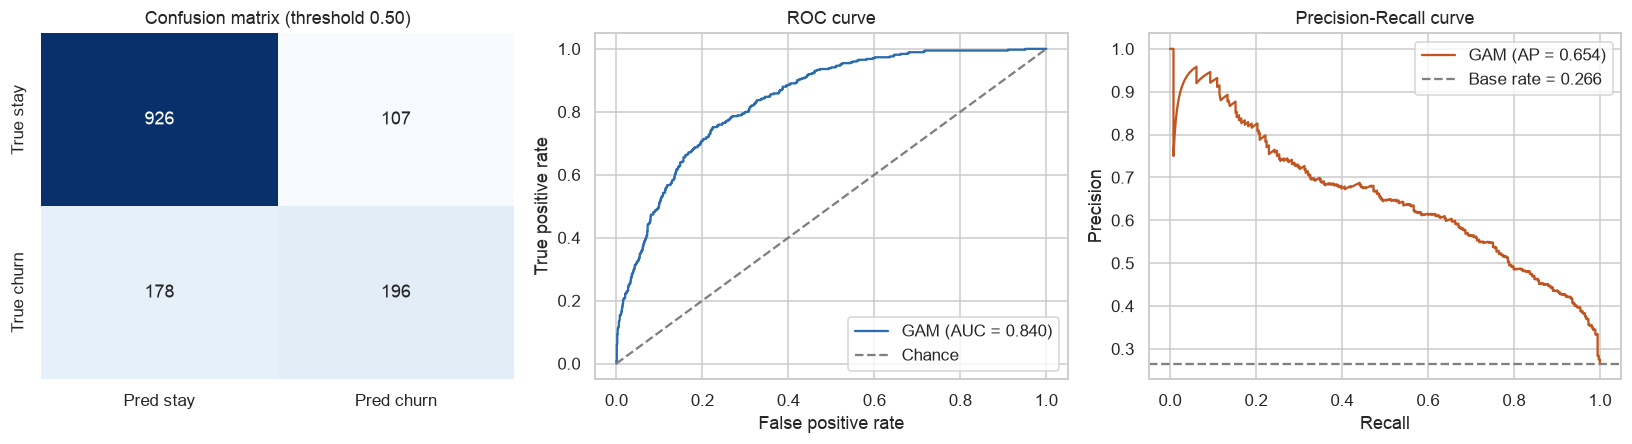

In [16]:
cm = confusion_matrix(y_test, pred_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred stay", "Pred churn"],
            yticklabels=["True stay", "True churn"], ax=axes[0])
axes[0].set_title("Confusion matrix (threshold 0.50)")

fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[1].plot(fpr, tpr, color="#2b6cb0", label=f"GAM (AUC = {metrics['ROC-AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], "--", color="grey", label="Chance")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve")
axes[1].legend(loc="lower right")

prec, rec, _ = precision_recall_curve(y_test, proba_test)
axes[2].plot(rec, prec, color="#c05621", label=f"GAM (AP = {metrics['PR-AUC']:.3f})")
axes[2].axhline(y_test.mean(), ls="--", color="grey", label=f"Base rate = {y_test.mean():.3f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall curve")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

### 4.1 Are the predicted probabilities trustworthy?

If the company plans to target the "top 10% highest-risk customers" with a retention offer, the *ranking* has
to be good. If it plans to say "this customer has a 60% chance of leaving", the *calibration* has to be good
too. The reliability curve below bins customers by predicted risk and compares predicted to observed churn.

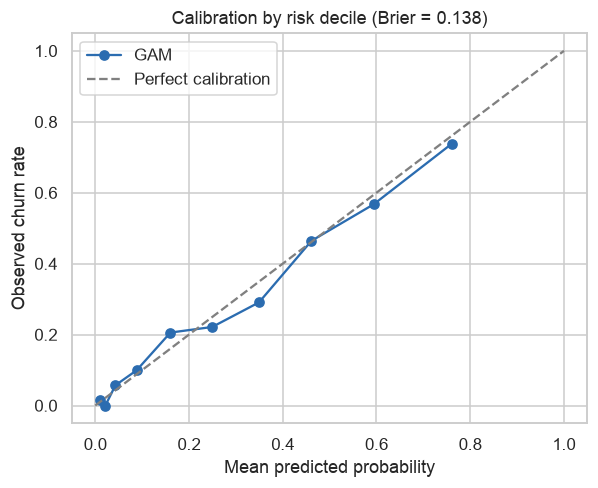

,predicted,observed,n
decile,,,
0,0.010,0.014,141
1,0.022,0.000,141
2,0.043,0.057,140
3,0.088,0.099,141
4,0.160,0.206,141
5,0.249,0.221,140
6,0.349,0.291,141
7,0.461,0.464,140
8,0.594,0.567,141


In [17]:
cal = pd.DataFrame({"p": proba_test, "y": y_test})
cal["decile"] = pd.qcut(cal["p"], 10, labels=False, duplicates="drop")
summary = cal.groupby("decile").agg(predicted=("p", "mean"), observed=("y", "mean"), n=("y", "size"))

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.plot(summary["predicted"], summary["observed"], "o-", color="#2b6cb0", label="GAM")
ax.plot([0, 1], [0, 1], "--", color="grey", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed churn rate")
ax.set_title(f"Calibration by risk decile (Brier = {metrics['Brier score']:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

summary.round(3)

The points track the diagonal closely across the whole range, so the predicted probabilities can be read as
probabilities and not just as scores. The lowest-risk decile is predicted at ~1% and observes ~1%; the
highest-risk decile is predicted at ~76% and observes ~74%.

### 4.2 Cross-validation and a logistic-regression baseline

One split can flatter a model. Five-fold stratified CV shows how stable the AUC is. I also fit a plain
logistic regression on the identical features — this is the comparison the team README needs, because it
answers "what did the extra flexibility of the splines actually buy us?"

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_auc = []
for train_idx, test_idx in cv.split(X.values, y):
    fold_model = LogisticGAM(terms)
    fold_model.gridsearch(X.values[train_idx], y[train_idx], progress=False)
    fold_auc.append(roc_auc_score(y[test_idx], fold_model.predict_proba(X.values[test_idx])))

print("GAM 5-fold CV ROC-AUC: {:.4f} (+/- {:.4f})".format(np.mean(fold_auc), np.std(fold_auc)))
print("Fold scores:", [round(a, 4) for a in fold_auc])

GAM 5-fold CV ROC-AUC: 0.8488 (+/- 0.0046)
Fold scores: [0.849, 0.856, 0.8484, 0.8493, 0.8415]


In [19]:
X_raw = df[FEATURES]
X_raw_train, X_raw_test, y_lr_train, y_lr_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocess = ColumnTransformer(
    [
        ("num", StandardScaler(), CONTINUOUS),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL),
    ]
)
logreg = make_pipeline(preprocess, LogisticRegression(max_iter=2000))
logreg.fit(X_raw_train, y_lr_train)

proba_lr = logreg.predict_proba(X_raw_test)[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int)

comparison = pd.DataFrame(
    {
        "GAM (splines)": metrics,
        "Logistic regression (linear)": {
            "Accuracy": accuracy_score(y_lr_test, pred_lr),
            "Precision": precision_score(y_lr_test, pred_lr),
            "Recall": recall_score(y_lr_test, pred_lr),
            "F1": f1_score(y_lr_test, pred_lr),
            "ROC-AUC": roc_auc_score(y_lr_test, proba_lr),
            "PR-AUC": average_precision_score(y_lr_test, proba_lr),
            "Brier score": brier_score_loss(y_lr_test, proba_lr),
        },
    }
).round(4)

comparison

,GAM (splines),Logistic regression (linear)
Accuracy,0.7974,0.8031
Precision,0.6469,0.6483
Recall,0.5241,0.5668
F1,0.5790,0.6049
ROC-AUC,0.8398,0.8344
PR-AUC,0.6541,0.6223
Brier score,0.1381,0.1402


**Performance summary.** Test ROC-AUC **0.840**, PR-AUC **0.654** against a 0.265 base rate, Brier **0.138**,
accuracy **0.797**. Five-fold CV gives **0.849 ± 0.005**, and the train-test AUC gap is small, so the model is
not overfitting despite the splines.

The honest headline for the team is that the GAM's ranking is **essentially tied** with logistic regression
(0.840 vs 0.834 AUC; the GAM is a little better on PR-AUC, the logistic model a little better on recall at the
0.50 threshold). The curved `tenure` and `MonthlyCharges` effects buy a better *description* of how risk
changes, not a meaningfully better prediction. That trade-off is the core of our recommendation.

## 5. Smooth effect interpretation

This is where a GAM pays off. Each partial dependence plot is the fitted $f_j$ — the feature's contribution
to the **log-odds** of churn, holding everything else fixed. Zero on the y-axis is the average customer; above
zero raises churn risk, below zero lowers it. Because the model is additive, these curves are the *whole*
model: no interaction is hiding behind them.

The shaded bands are 95% confidence intervals. Where they widen, the data is thin and the curve should not be
over-read.

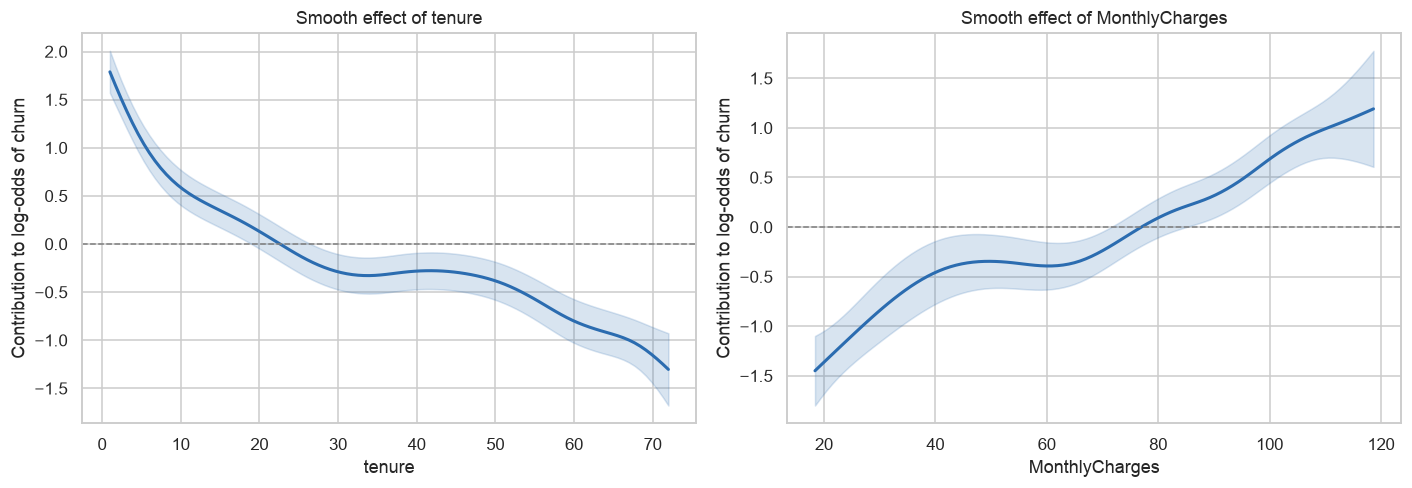

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for ax, (i, name) in zip(axes, enumerate(CONTINUOUS)):
    grid = gam.generate_X_grid(term=i)
    pdep, conf = gam.partial_dependence(term=i, X=grid, width=0.95)
    ax.plot(grid[:, i], pdep, color="#2b6cb0", lw=2)
    ax.fill_between(grid[:, i], conf[:, 0], conf[:, 1], color="#2b6cb0", alpha=0.18)
    ax.axhline(0, color="grey", ls="--", lw=1)
    ax.set_xlabel(name)
    ax.set_ylabel("Contribution to log-odds of churn")
    ax.set_title(f"Smooth effect of {name}")

plt.tight_layout()
plt.show()

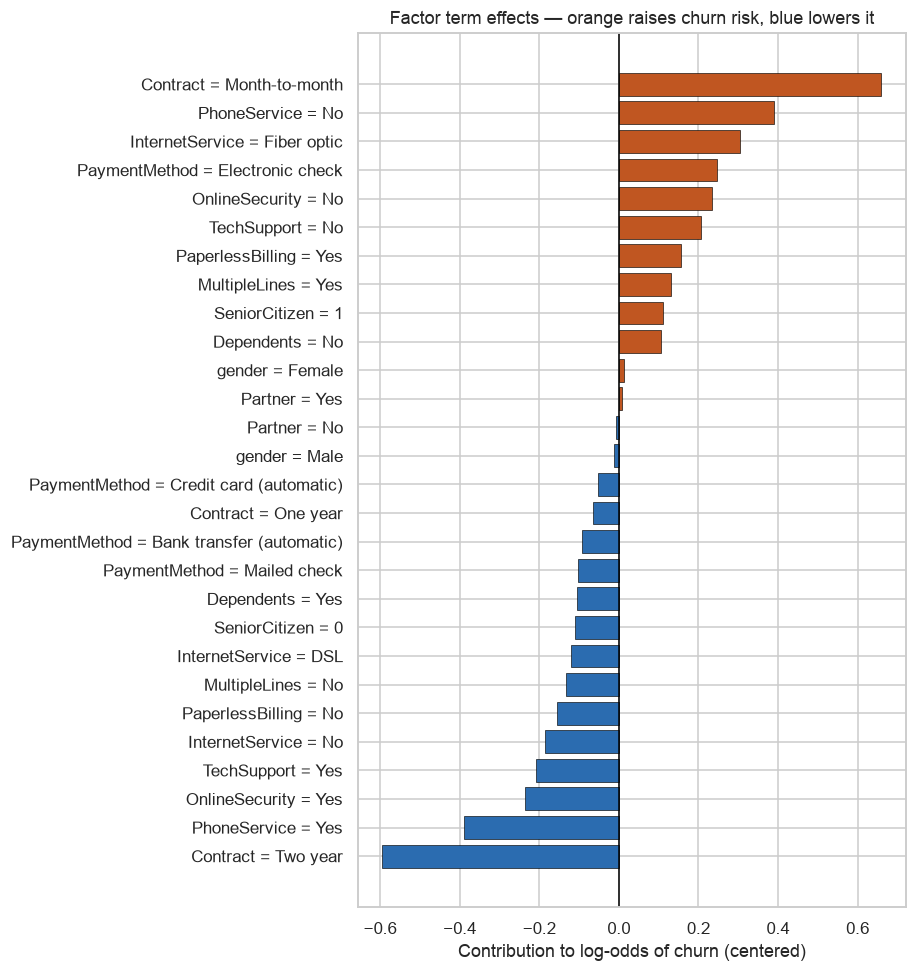

,feature,level,log_odds,odds_ratio,label
0,Contract,Month-to-month,0.660,1.935,Contract = Month-to-month
1,PhoneService,No,0.390,1.478,PhoneService = No
2,InternetService,Fiber optic,0.305,1.356,InternetService = Fiber optic
3,PaymentMethod,Electronic check,0.248,1.281,PaymentMethod = Electronic check
4,OnlineSecurity,No,0.235,1.265,OnlineSecurity = No
5,TechSupport,No,0.207,1.230,TechSupport = No
6,PaperlessBilling,Yes,0.155,1.168,PaperlessBilling = Yes
7,MultipleLines,Yes,0.132,1.141,MultipleLines = Yes
8,SeniorCitizen,1,0.111,1.117,SeniorCitizen = 1
9,Dependents,No,0.105,1.111,Dependents = No


In [21]:
rows = []
baseline = X_train.mean(axis=0)
for i, name in enumerate(CATEGORICAL, start=len(CONTINUOUS)):
    for code_value in sorted(np.unique(X_train[:, i]).astype(int)):
        probe = baseline.copy()
        probe[i] = code_value
        effect = gam.partial_dependence(term=i, X=probe.reshape(1, -1))[0]
        rows.append(
            {
                "feature": name,
                "level": str(category_levels[name][code_value]),
                "log_odds": effect,
                "odds_ratio": np.exp(effect),
            }
        )

factor_effects = pd.DataFrame(rows)
factor_effects["label"] = factor_effects["feature"] + " = " + factor_effects["level"]
ordered = factor_effects.sort_values("log_odds")

fig, ax = plt.subplots(figsize=(8.5, 9))
colors = ["#c05621" if v > 0 else "#2b6cb0" for v in ordered["log_odds"]]
ax.barh(ordered["label"], ordered["log_odds"], color=colors, edgecolor="black", lw=0.4)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Contribution to log-odds of churn (centered)")
ax.set_title("Factor term effects — orange raises churn risk, blue lowers it")
plt.tight_layout()
plt.show()

factor_effects.sort_values("log_odds", ascending=False).round(3).reset_index(drop=True)

### 5.1 Reading the smooths

**`tenure` — a steep early cliff, then a slow decline.** The curve starts at about **+1.79 log-odds** at month 1,
falls to **+0.84** by month 7 and crosses zero around **month 22**. That first stretch is the whole story: over
the first six months a customer's churn contribution drops by roughly 0.95 log-odds, about **2.6× lower odds**
of leaving. Between months 30 and 45 the curve is essentially flat (hovering near −0.30), then it declines
again to about **−1.30** at month 72.

That flat middle is exactly what a straight line cannot represent. A linear model would spread one average
slope across the early cliff, the plateau, and the late decline, understating the risk of brand-new customers
and overstating the marginal benefit of each additional month for a two-year customer. Operationally the
curve says: **churn risk is concentrated in the first six months**, and a customer who reaches roughly month 22
is below average risk.

**`MonthlyCharges` — two steep ends with a flat plateau between them.** The effect starts at **−1.45** for the
cheapest plans (~$18/month) and rises quickly to about **−0.35** by $47. It then goes flat, sitting between
**−0.35 and −0.39** all the way through the $47–$64 mid-market, crosses zero near **$77**, and climbs steeply
again to **+1.19** at the top of the range (~$119).

So price is not one effect but three regimes: strongly protective at the bottom, essentially neutral across the
middle, and sharply risky above roughly $75/month, which is where the fiber plans live. A linear term would
average the flat plateau together with the steep upper arm and describe neither.

This smooth is also the clearest example of why the distinction from section 2.2 matters. **Marginally**, the
most expensive customers churn *less* (22% in the top price decile). **Conditionally**, this curve says that
between two customers on the same contract, with the same tenure and the same services, the one paying more is
at higher risk. Both statements are true and they answer different questions. The GAM answers the second one,
and it is the second one a pricing decision would depend on.

**Factor terms.** `Contract` dominates: month-to-month sits at **+0.66 log-odds** and two-year at **−0.59**, a
gap of about 1.25 log-odds (**odds ratio ≈ 3.5** between the two ends). `Electronic check` payment (+0.25),
fiber internet (+0.31), and the absence of `OnlineSecurity` (+0.24) or `TechSupport` (+0.21) all raise risk.
`gender` (±0.01) and `Partner` (±0.01) are effectively zero, which is a useful negative result: the model finds
no gender signal in churn.

One counterintuitive term deserves a flag rather than an explanation: `PhoneService = No` shows **+0.39**.
Customers without phone service are internet-only accounts, so this term is likely absorbing something about
that segment rather than describing a phone effect. It is a good example of why an additive coefficient
should not be read as a lever to pull.

## 6. Limitations of a GAM for churn

**1. Additivity is assumed, and section 2.4 showed it is strained.** This is the main limitation. The model
fits *one* tenure curve and *one* contract offset, but the data shows the fiber-optic penalty is far larger
for month-to-month customers than for two-year customers, and the tenure curves for the three contract types
are not parallel. Every interpretation in section 5 is therefore an average across contract types, not a
description of any particular customer segment. Acting on the fiber effect as if it applied equally to
everyone would over-target long-contract customers and under-target the month-to-month segment where the risk
actually concentrates.

**2. The added flexibility bought description, not accuracy.** ROC-AUC 0.840 versus 0.834 for logistic
regression is within noise. If the company only needs a ranked risk list, the GAM's extra machinery — spline
bases, a smoothing parameter to tune, partial dependence plots to explain — is cost without benefit. The GAM
is worth it only if the *shape* of the tenure and price effects is itself the deliverable.

**3. Smooth effects are harder to communicate and easier to over-read.** A logistic regression gives one
number per feature that a retention manager can put in a slide. A GAM gives a curve, and curves invite
over-interpretation of local wiggles that are inside the confidence band. The tenure curve's slight uptick
around months 36–42 is not a real phenomenon; it is within the interval width. Confidence bands widen at the
edges (the tenure interval at month 72 spans −1.68 to −0.93), so the extremes are the least reliable part of
the plot and are exactly where the eye is drawn.

**4. The p-values in the summary are not trustworthy as inference.** pygam warns about this directly: λ was
estimated from the same data used for the tests, so the p-values reject the null too readily. They rank terms;
they do not establish significance.

**5. Nothing here is causal.** The curves are associations under a specific set of controls. "Move customers to
two-year contracts to cut churn by an odds ratio of 3.5" does not follow — customers who *choose* long
contracts are already the ones who intended to stay. Contract type is partly a marker of prior intent, not
only a treatment.

**6. Concurvity forced a modeling choice that hides information.** I dropped `TotalCharges` because a spline of
`tenure` explains ~69% of it. That was the right call for stable curves, but it means the model has no term
for cumulative spend, and any real relationship there is now folded silently into the tenure and charges
smooths.

**7. It is a single snapshot.** Churn is a timing process — *when* someone leaves, with censored observations
for those who have not left yet. A binary GAM on one cross-section cannot express that, cannot capture
seasonality or competitor actions, and assumes today's relationships hold at deployment time.

## 7. Takeaways for the team README

**Assumption checks (GAM row).** Checked link/distribution (binary target, logit), independence (7,032 unique
IDs, one row each), smoothness and support (72 distinct tenure values, both continuous effects clearly
nonlinear on the empirical log-odds plots), concurvity (spline $R^2$ of tenure → TotalCharges = 0.69, so
TotalCharges dropped; tenure → MonthlyCharges = 0.07, so both retained), and additivity (churn rate by
Contract × InternetService shows the fiber penalty varies from ~22 points for month-to-month customers to ~5
points for two-year customers). **Concern: additivity is violated in a way the model cannot express.**

**Performance evidence.** Test ROC-AUC 0.840, PR-AUC 0.654 (base rate 0.265), Brier 0.138, accuracy 0.797,
recall 0.524 at threshold 0.50. Five-fold CV AUC 0.849 ± 0.005. Well calibrated across all ten risk deciles.

**Interpretability strength.** Recovers effect *shapes* that a linear model has to assume away: the first-six-
months churn cliff in tenure and the U-shaped price effect. Each effect is still one readable plot because the
model stays additive.

**Interpretability weakness.** Effects are curves rather than single numbers, so they are harder to summarize
and easier to over-read; the smoothing parameter is an analyst choice that changes the shape; and the reported
p-values are unreliable after λ estimation.

**My recommendation for the team discussion.** Logistic regression is the better *deployment* model here — it
matches the GAM's accuracy with simpler, more communicable coefficients. But the GAM should be run first as a
diagnostic, because it is what reveals that `tenure` and `MonthlyCharges` are non-linear. That finding should
feed back into the logistic model as a tenure spline or binned tenure term rather than being ignored.

**Next analysis I would run.** Fit a GAM with a tensor-product interaction between `tenure` and `Contract`
(`te(0, 11)` in pygam) and compare it to this additive model by AIC and CV AUC. That directly tests the
additivity violation found in section 2.4 and tells us whether the retention story needs to be told separately
per contract type.